In [ ]:
from google.colab import files
uploaded = files.upload()

Saving student_performances.csv to student_performances (1).csv


# In this tutorial you are given a task of classifying students grades bases on various properties of the students and their families. The students can have 5 kinds of grades - Excellent, Very good, Good, Satisfactory, and poor.

# You need to develop different classifiers and determine which one of them give best performaces on various metrices.

# Import Libraries.
## I have imported few new libraries for this week  but you need to import rest of them.

In [1]:

# Your code to import all the relevant libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Read and display dataset.

In [2]:
# Your code to read data
dataset = pd.read_csv("student_performances.csv")
# Your code to print first few samples of the dataset.
dataset.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,...,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,grades
0,F,18,U,GT3,A,4,4,at_home,teacher,course,...,no,no,4,3,4,1,1,3,6,poor
1,F,17,U,GT3,T,1,1,at_home,other,course,...,yes,no,5,3,3,1,1,3,4,poor
2,F,15,U,LE3,T,1,1,at_home,other,other,...,yes,no,4,3,2,2,3,3,10,satisfactory
3,F,15,U,GT3,T,4,2,health,services,home,...,yes,yes,3,2,2,1,1,5,2,very good
4,F,16,U,GT3,T,3,3,other,other,home,...,no,no,4,3,2,1,2,5,4,satisfactory


# Print the information about the dataset.

## You need to convert all the object datatypes (except output variable - grades) to the numbers using either labelencoding or one hot encoding.

In [3]:
# Your code to print the key information about the datset. Use - .info method.
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   sex         395 non-null    object
 1   age         395 non-null    int64 
 2   address     395 non-null    object
 3   famsize     395 non-null    object
 4   Pstatus     395 non-null    object
 5   Medu        395 non-null    int64 
 6   Fedu        395 non-null    int64 
 7   Mjob        395 non-null    object
 8   Fjob        395 non-null    object
 9   reason      395 non-null    object
 10  guardian    395 non-null    object
 11  traveltime  395 non-null    int64 
 12  studytime   395 non-null    int64 
 13  failures    395 non-null    int64 
 14  schoolsup   395 non-null    object
 15  famsup      395 non-null    object
 16  paid        395 non-null    object
 17  activities  395 non-null    object
 18  nursery     395 non-null    object
 19  higher      395 non-null    object
 20  internet  

# Converting the columns  ['Fjob', 'Mjob', 'reason', 'guardian'] into one hot vectors.

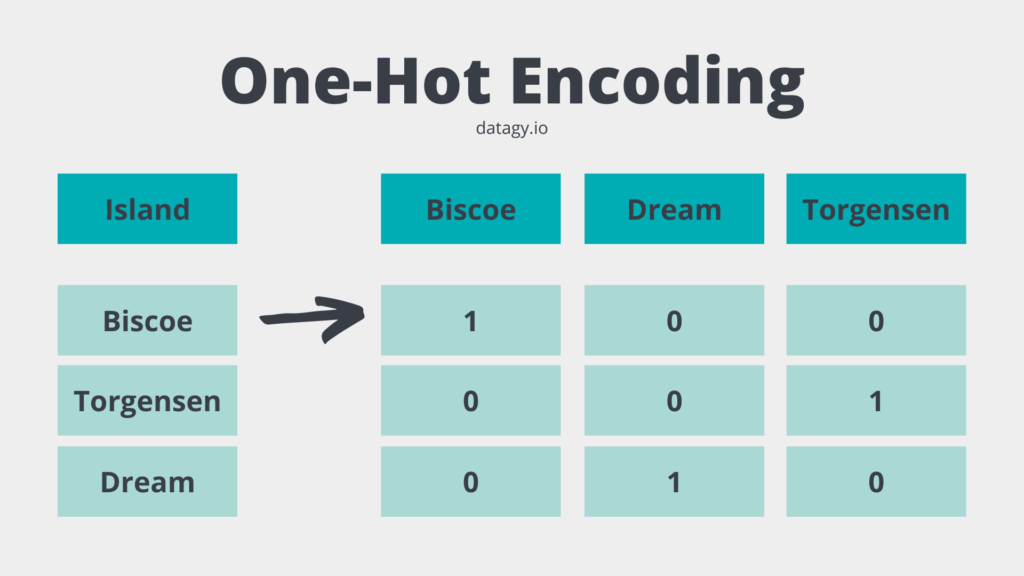

In [4]:
data = pd.get_dummies(dataset, columns = ['Fjob', 'Mjob', 'reason', 'guardian'])


# Note that you can also use sklearn.preprocessing.OneHotEncoder instead of pd.get_dummies.

# Next, print the first few rows of the data (dataset have been stored in data in previous cell).

In [5]:
# Your code to print first few rows of the data.
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_other,Mjob_services,Mjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,F,18,U,GT3,A,4,4,2,2,0,...,0,0,0,1,0,0,0,0,1,0
1,F,17,U,GT3,T,1,1,1,2,0,...,0,0,0,1,0,0,0,1,0,0
2,F,15,U,LE3,T,1,1,1,2,3,...,0,0,0,0,0,1,0,0,1,0
3,F,15,U,GT3,T,4,2,1,3,0,...,0,0,0,0,1,0,0,0,1,0
4,F,16,U,GT3,T,3,3,1,2,0,...,1,0,0,0,1,0,0,1,0,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sex                395 non-null    object
 1   age                395 non-null    int64 
 2   address            395 non-null    object
 3   famsize            395 non-null    object
 4   Pstatus            395 non-null    object
 5   Medu               395 non-null    int64 
 6   Fedu               395 non-null    int64 
 7   traveltime         395 non-null    int64 
 8   studytime          395 non-null    int64 
 9   failures           395 non-null    int64 
 10  schoolsup          395 non-null    object
 11  famsup             395 non-null    object
 12  paid               395 non-null    object
 13  activities         395 non-null    object
 14  nursery            395 non-null    object
 15  higher             395 non-null    object
 16  internet           395 non-null    object
 1

# Converting other text values in the dataframe to numbers using label encoding.

In [7]:
labelencoder = LabelEncoder()

labelencoder.fit(data['sex'])
data ['sex'] = labelencoder.transform(data['sex'])

#
## Your code to convert transform address to the numbers
#
labelencoder.fit(data['address'])
data ['address'] = labelencoder.transform(data['address'])

#
## Your code to convert transform famsize to the numbers
#
labelencoder.fit(data['famsize'])
data ['famsize'] = labelencoder.transform(data['famsize'])

#
## Your code to convert transform Pstatus to the numbers
#
labelencoder.fit(data['Pstatus'])
data ['Pstatus'] = labelencoder.transform(data['Pstatus'])

#
## Your code to convert transform schoolsup to the numbers
#

labelencoder.fit(data['schoolsup'])
data ['schoolsup'] = labelencoder.transform(data['schoolsup'])
#
## Your code to convert transform famsup to the numbers
#
labelencoder.fit(data['famsup'])
data ['famsup'] = labelencoder.transform(data['famsup'])
#
## Your code to convert transform paid to the numbers
#
labelencoder.fit(data['paid'])
data ['paid'] = labelencoder.transform(data['paid'])

#
## Your code to convert transform activities to the numbers
#

labelencoder.fit(data['activities'])
data ['activities'] = labelencoder.transform(data['activities'])
#
## Your code to convert transform nursery to the numbers
#

labelencoder.fit(data['nursery'])
data ['nursery'] = labelencoder.transform(data['nursery'])
#
## Your code to convert transform higher to the numbers
#
labelencoder.fit(data['higher'])
data ['higher'] = labelencoder.transform(data['higher'])

#
## Your code to convert transform internet to the numbers
#
labelencoder.fit(data['internet'])
data ['internet'] = labelencoder.transform(data['internet'])
#
## Your code to convert transform romantic to the numbers
#
labelencoder.fit(data['romantic'])
data ['romantic'] = labelencoder.transform(data['romantic'])

# Is their an efficient way to do this? Could you use loops. Try to convert it into an efficient code and replace with the above code?


# Next - Print few samples of the data to ensure everything is number except 'grades' column.

In [8]:
# Your code to print first few samples of the data.
data.head()

,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,failures,...,Mjob_other,Mjob_services,Mjob_teacher,reason_course,reason_home,reason_other,reason_reputation,guardian_father,guardian_mother,guardian_other
0,0,18,1,0,0,4,4,2,2,0,...,0,0,0,1,0,0,0,0,1,0
1,0,17,1,0,1,1,1,1,2,0,...,0,0,0,1,0,0,0,1,0,0
2,0,15,1,1,1,1,1,1,2,3,...,0,0,0,0,0,1,0,0,1,0
3,0,15,1,0,1,4,2,1,3,0,...,0,0,0,0,1,0,0,0,1,0
4,0,16,1,0,1,3,3,1,2,0,...,1,0,0,0,1,0,0,1,0,0


In [9]:
# Your code to print information on the samples of data.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   sex                395 non-null    int32 
 1   age                395 non-null    int64 
 2   address            395 non-null    int32 
 3   famsize            395 non-null    int32 
 4   Pstatus            395 non-null    int32 
 5   Medu               395 non-null    int64 
 6   Fedu               395 non-null    int64 
 7   traveltime         395 non-null    int64 
 8   studytime          395 non-null    int64 
 9   failures           395 non-null    int64 
 10  schoolsup          395 non-null    int32 
 11  famsup             395 non-null    int32 
 12  paid               395 non-null    int32 
 13  activities         395 non-null    int32 
 14  nursery            395 non-null    int32 
 15  higher             395 non-null    int32 
 16  internet           395 non-null    int32 
 1

# Separate input X and output y.

## X is the all columns except 'grades'.
## y is 'grades' column.

In [10]:
data['paid'].value_counts()

0    214
1    181
Name: paid, dtype: int64

In [11]:
# Your code to get X from data
X = data.drop('grades',axis=1).values
# Your code to get y from data
data['grades'].value_counts()


poor            130
satisfactory    103
good             62
very good        60
excellent        40
Name: grades, dtype: int64

In [12]:
labelencoder.fit(data['grades'])
data ['grades'] = labelencoder.transform(data['grades'])


In [13]:
data['grades'].value_counts()

2    130
3    103
1     62
4     60
0     40
Name: grades, dtype: int64

In [14]:
y = data['grades'].values

# Print shapes of X and y to make sure everything is good

In [15]:
# Print shape of X
X.shape
# Print shape of y
# Print X
# Print y

(395, 42)

In [16]:
y.shape

(395,)

In [17]:
print(X)

[[ 0 18  1 ...  0  1  0]
 [ 0 17  1 ...  1  0  0]
 [ 0 15  1 ...  0  1  0]
 ...
 [ 1 21  0 ...  0  0  1]
 [ 1 18  0 ...  0  1  0]
 [ 1 19  1 ...  1  0  0]]


In [18]:
print(y)

[2 2 3 4 3 4 3 2 0 4 2 1 4 3 0 4 4 3 2 3 4 4 0 1 2 2 3 4 3 3 1 0 0 1 4 2 0
 4 3 1 3 1 0 3 2 2 3 0 4 2 1 1 3 3 1 3 4 4 2 0 3 3 2 2 3 4 1 2 2 0 4 3 2 4
 3 3 3 3 3 2 1 3 2 4 3 2 2 4 3 2 2 0 2 3 4 3 4 3 4 2 2 0 4 2 0 3 2 0 1 0 0
 3 1 0 2 0 4 1 2 1 4 4 1 1 2 1 3 2 2 0 2 2 1 3 2 2 2 2 1 4 2 2 3 1 2 3 2 3
 2 3 2 4 3 2 1 2 1 3 4 1 2 2 2 3 2 1 3 0 2 4 2 0 3 2 2 2 3 2 2 3 2 1 0 2 1
 3 3 4 2 3 1 2 2 3 4 4 0 3 0 3 0 3 3 2 3 2 2 1 3 2 2 1 4 2 3 4 2 2 2 3 2 2
 0 1 4 2 4 1 2 1 4 3 2 1 2 3 1 1 3 2 1 1 2 1 2 0 1 2 2 4 2 3 2 2 1 2 1 3 4
 2 0 2 1 2 2 0 3 3 3 2 2 4 3 4 3 1 2 2 2 3 2 3 1 3 3 3 0 1 4 4 3 4 1 0 4 3
 2 2 4 0 3 3 4 0 1 1 0 2 1 3 2 1 3 3 1 3 2 2 3 3 1 2 3 4 4 3 0 3 2 4 2 4 2
 2 2 4 1 2 0 3 3 2 4 2 3 4 0 2 4 1 2 1 2 2 3 2 1 3 3 0 1 1 3 4 1 3 1 2 3 3
 2 1 3 2 0 3 4 3 4 3 4 2 3 2 2 3 2 2 2 2 2 0 2 3 2]


# Next  - Split data into train and test set.

In [19]:
# Your code to split data into train and test set.
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.2, random_state = 1)

#
#
# Print shapes of train and test data to make sure everyhing is in order.
#
#

In [20]:

X_train.shape

(316, 42)

In [21]:

y_train.shape

(316,)

In [22]:

X_test.shape

(79, 42)

In [23]:

y_test.shape

(79,)

In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 43 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   sex                395 non-null    int32
 1   age                395 non-null    int64
 2   address            395 non-null    int32
 3   famsize            395 non-null    int32
 4   Pstatus            395 non-null    int32
 5   Medu               395 non-null    int64
 6   Fedu               395 non-null    int64
 7   traveltime         395 non-null    int64
 8   studytime          395 non-null    int64
 9   failures           395 non-null    int64
 10  schoolsup          395 non-null    int32
 11  famsup             395 non-null    int32
 12  paid               395 non-null    int32
 13  activities         395 non-null    int32
 14  nursery            395 non-null    int32
 15  higher             395 non-null    int32
 16  internet           395 non-null    int32
 17  romantic        

# Next - Develop a SVM classifier and fit into the train dataset.

In [25]:
classifier = SVC(kernel = 'rbf')
classifier.fit(X_train, y_train)

SVC()

# Next - prdict the values on the input test set.

# Find accuracy, precision, recall, f-score.

In [26]:
y_pred = classifier.predict(X_test)

print (print("Accuracy test set: ", accuracy_score(y_test, y_pred)))
acc1 = accuracy_score(y_test, y_pred)
print (print("Precision test set: ", precision_score(y_test, y_pred, average = 'micro' )))
prec1 = precision_score(y_test, y_pred, average = 'micro' )
print (print("Recall test set: ", recall_score(y_test, y_pred, average = 'micro' )))
rec1 = recall_score(y_test, y_pred, average = 'micro' )
print (print("F-score test set: ", f1_score(y_test, y_pred, average = 'micro' )))
fs1 = f1_score(y_test, y_pred, average = 'micro')

print (classification_report(y_test, y_pred))

Accuracy test set:  0.3037974683544304
None
Precision test set:  0.3037974683544304
None
Recall test set:  0.3037974683544304
None
F-score test set:  0.3037974683544304
None
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.00      0.00      0.00        12
           2       0.30      1.00      0.47        24
           3       0.00      0.00      0.00        30
           4       0.00      0.00      0.00         7

    accuracy                           0.30        79
   macro avg       0.06      0.20      0.09        79
weighted avg       0.09      0.30      0.14        79



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Find accuracy, precision, recall, and f-score on training dataset.

In [28]:
train_data_predictions = classifier.predict(X_train)

print (print("Accuracy train set: ", accuracy_score(y_train, train_data_predictions)))
print (print("Precision train set: ", precision_score(y_train, train_data_predictions, average = 'micro' )))
print (print("Recall train set: ", recall_score(y_train, train_data_predictions, average = 'micro' )))
print (print("F-score train set: ", f1_score(y_train, train_data_predictions, average = 'micro' )))

print (classification_report(y_train, train_data_predictions))

Accuracy train set:  0.33544303797468356
None
Precision train set:  0.33544303797468356
None
Recall train set:  0.33544303797468356
None
F-score train set:  0.33544303797468356
None
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        34
           1       0.00      0.00      0.00        50
           2       0.34      1.00      0.50       106
           3       0.00      0.00      0.00        73
           4       0.00      0.00      0.00        53

    accuracy                           0.34       316
   macro avg       0.07      0.20      0.10       316
weighted avg       0.11      0.34      0.17       316



C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Display confusion matrix between actual and predicted values on the test data.

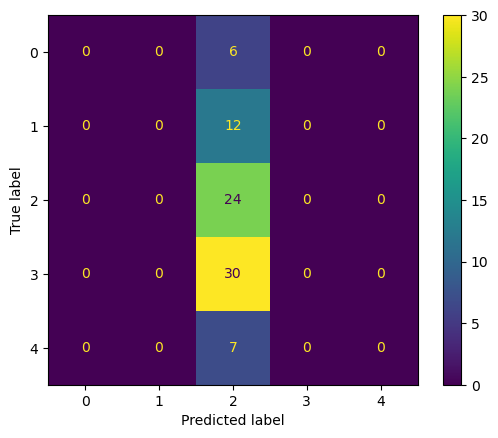

In [29]:
#
# Your code to display confusion matrix between predicted output and actual output
#
#
cmatrix = confusion_matrix(y_test, y_pred, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=classifier.classes_)
disp.plot()

# Earlier, we used rfb Kernel. Now, we will test other kernels too.

# We will test on ['linear', 'poly', 'rbf', 'sigmoid' ] kernels.

In [30]:
# Create a list kernels with values ['linear', 'poly', 'rbf', 'sigmoid' ]
# Create an empty list accuracy
kernels =  ['linear', 'poly', 'rbf', 'sigmoid' ]
accuracy = []
for i in kernels:
    classifier = SVC(kernel = i)
    classifier.fit(X_train, y_train)
    test_pred = classifier.predict(X_test)
    test_score = accuracy_score(y_test, test_pred)
    test_scores = accuracy.append(test_score)
    
  #
  #
  # Your code to compare the classifier for different Kernesls
  #
  #

#
# Your code to plot accuracy vs kernels
#

In [31]:
accuracy

[0.27848101265822783,
 0.3037974683544304,
 0.3037974683544304,
 0.27848101265822783]

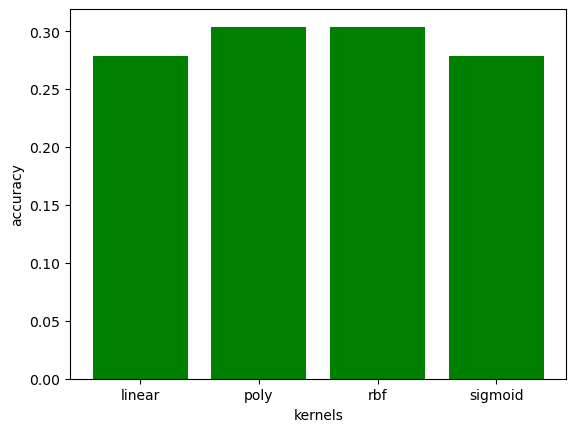

In [32]:
plt.figure
plt.bar(kernels, accuracy, color = 'green')
plt.xlabel('kernels')
plt.ylabel('accuracy')
plt.show()

# Which Kernel function is giving you best accuracy?

# Next - Develop KNN and Losgistic regression classifiers for this dataset.

In [33]:
#
# Develop KNN-based classifier. Use number of neigbours of your choice
#
# Your code to separate train and test sets.
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size = 0.3, random_state = 42)

# Your code to Print the shapes of the X_train, X_test, y_train, y_test
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(276, 42)
(119, 42)
(276,)
(119,)


In [34]:
from sklearn.neighbors import KNeighborsClassifier

In [35]:
knn = KNeighborsClassifier(n_neighbors = 5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

# Evaluate KNN for accuracy, precision, recall, f-score, and classification report on test data.

In [41]:
#
#
# Your code to evaluate the classifer on test data
#
#
y_pred2 = knn.predict(X_test)

print (print("Accuracy test set: ", accuracy_score(y_test, y_pred2)))
acc2 = accuracy_score(y_test, y_pred2)
print (print("Precision test set: ", precision_score(y_test, y_pred2, average = 'micro' )))
prec2 = precision_score(y_test, y_pred2, average = 'micro' )
print (print("Recall test set: ", recall_score(y_test, y_pred2, average = 'micro' )))
rec2 = recall_score(y_test, y_pred2, average = 'micro' )
print (print("F-score test set: ", f1_score(y_test, y_pred2, average = 'micro' )))
fs2 = f1_score(y_test, y_pred2, average = 'micro')

print (classification_report(y_test, y_pred2))

Accuracy test set:  0.29411764705882354
None
Precision test set:  0.29411764705882354
None
Recall test set:  0.29411764705882354
None
F-score test set:  0.29411764705882354
None
              precision    recall  f1-score   support

           0       0.40      0.29      0.33        14
           1       0.11      0.20      0.14        15
           2       0.50      0.35      0.41        46
           3       0.22      0.29      0.25        24
           4       0.29      0.25      0.27        20

    accuracy                           0.29       119
   macro avg       0.30      0.28      0.28       119
weighted avg       0.35      0.29      0.31       119



# Evaluate KNN for accuracy, precision, recall, f-score, and classification report on train data.



In [43]:
#
#
# Your code to evaluate the classifer on train data
#
#
train_data_predictions = knn.predict(X_train)

print (print("Accuracy train set: ", accuracy_score(y_train, train_data_predictions)))
print (print("Precision train set: ", precision_score(y_train, train_data_predictions, average = 'micro' )))
print (print("Recall train set: ", recall_score(y_train, train_data_predictions, average = 'micro' )))
print (print("F-score train set: ", f1_score(y_train, train_data_predictions, average = 'micro' )))

print (classification_report(y_train, train_data_predictions))

Accuracy train set:  0.5144927536231884
None
Precision train set:  0.5144927536231884
None
Recall train set:  0.5144927536231884
None
F-score train set:  0.5144927536231884
None
              precision    recall  f1-score   support

           0       0.38      0.35      0.36        26
           1       0.47      0.57      0.51        47
           2       0.63      0.65      0.64        84
           3       0.49      0.51      0.50        79
           4       0.42      0.28      0.33        40

    accuracy                           0.51       276
   macro avg       0.48      0.47      0.47       276
weighted avg       0.51      0.51      0.51       276



# Display confusion matric between predicted and actual values.

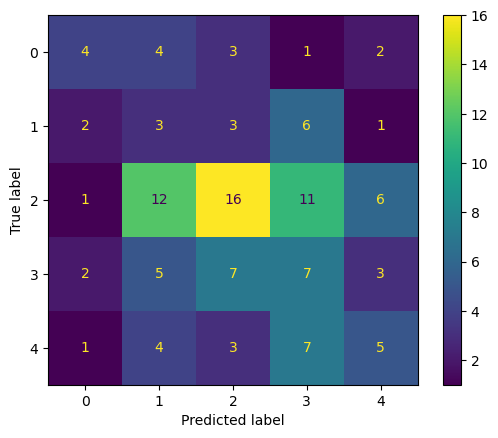

In [44]:
#
#
# Your code to display confusion matrix
#
cmatrix = confusion_matrix(y_test, y_pred2, labels=knn.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=knn.classes_)
disp.plot()

# Develop Logistic Regression-based classifier.

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
# Your code to develop logistic regression-based classifier
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=22)

In [46]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [48]:
logi = LogisticRegression(random_state = 2)
logi.fit(X_train, y_train)

LogisticRegression(random_state=2)

# Evaluate Logistic Regression for accuracy, precision, recall, f-score, and classification report on test data.

In [49]:
y_pred3 = logi.predict(X_test)
#
#
# Your code to evaluate the logistic regression classifier on test data
print (print("Accuracy test set: ", accuracy_score(y_test, y_pred3)))
acc3 = accuracy_score(y_test, y_pred3)
print (print("Precision test set: ", precision_score(y_test, y_pred3, average = 'micro' )))
prec3 = precision_score(y_test, y_pred3, average = 'micro' )
print (print("Recall test set: ", recall_score(y_test, y_pred3, average = 'micro' )))
rec3 = recall_score(y_test, y_pred3, average = 'micro' )
print (print("F-score test set: ", f1_score(y_test, y_pred3, average = 'micro' )))
fs3 = f1_score(y_test, y_pred3, average = 'micro')

print (classification_report(y_test, y_pred3))
#
#

Accuracy test set:  0.3291139240506329
None
Precision test set:  0.3291139240506329
None
Recall test set:  0.3291139240506329
None
F-score test set:  0.3291139240506329
None
              precision    recall  f1-score   support

           0       0.40      0.20      0.27        10
           1       0.27      0.27      0.27        11
           2       0.28      0.53      0.37        17
           3       0.40      0.25      0.31        24
           4       0.38      0.35      0.36        17

    accuracy                           0.33        79
   macro avg       0.35      0.32      0.32        79
weighted avg       0.35      0.33      0.32        79



# Evaluate Logistic regression for accuracy, precision, recall, f-score, and classification report on train data.

In [50]:
#
#
#
# Your code to evaluate the logistic regression classifier on train data
#
#
train_data_predictions = logi.predict(X_train)

print (print("Accuracy train set: ", accuracy_score(y_train, train_data_predictions)))
print (print("Precision train set: ", precision_score(y_train, train_data_predictions, average = 'micro' )))
print (print("Recall train set: ", recall_score(y_train, train_data_predictions, average = 'micro' )))
print (print("F-score train set: ", f1_score(y_train, train_data_predictions, average = 'micro' )))

print (classification_report(y_train, train_data_predictions))

Accuracy train set:  0.5411392405063291
None
Precision train set:  0.5411392405063291
None
Recall train set:  0.5411392405063291
None
F-score train set:  0.5411392405063291
None
              precision    recall  f1-score   support

           0       0.57      0.53      0.55        30
           1       0.50      0.27      0.35        51
           2       0.58      0.74      0.65       113
           3       0.49      0.44      0.46        79
           4       0.50      0.51      0.51        43

    accuracy                           0.54       316
   macro avg       0.53      0.50      0.51       316
weighted avg       0.53      0.54      0.53       316



# Display confusion matrix between predicted and actual values for logistic regression.

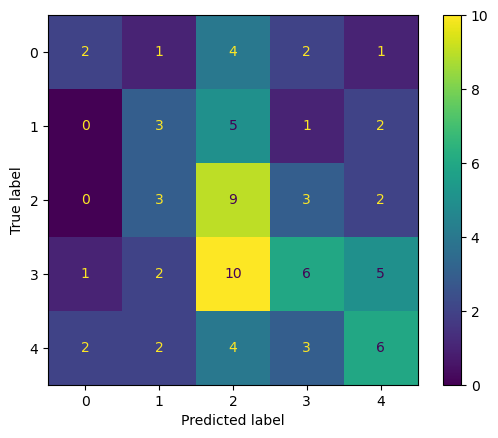

In [51]:
#
# Your code to display confusion matrix for logistic regression
cmatrix = confusion_matrix(y_test, y_pred3, labels=logi.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cmatrix, display_labels=logi.classes_)
disp.plot()

Next, compare the accuracy, precision, recall, and F-score for all the classifiers using plots. You need to have only one plot rather than 4 different plots for 4 different meteruces.

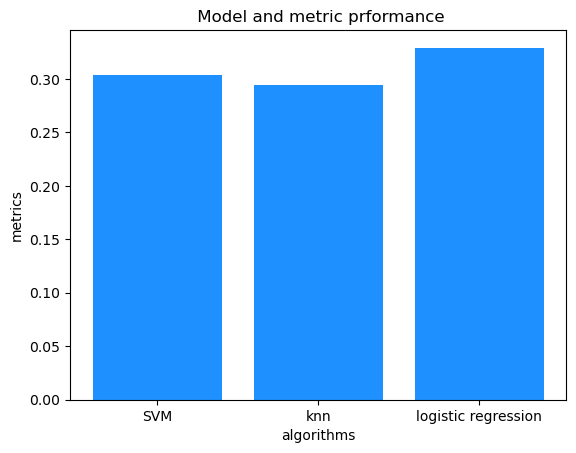

In [103]:
#
#
# Your code to plot and compare the performance of different algorithms
#
algorithms = ['SVM', 'knn', 'logistic regression']
accuracies = [acc1, acc2, acc3]
precisions = [ prec1, prec2, prec3]
recalls = [rec1, rec2, rec3]
fscores = [ fs1, fs2, fs3]
x = np.arange(len(algorithms))  # the label locations
width = 0.2  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - 3/2*width, accuracies, width, label='Accuracy', color = '#1E90FF')
rects2 = ax.bar(x - width/2, precisions, width, label='Precision', color = '#1E90FF')
rects3 = ax.bar(x + width/2, recalls, width, label='Recall', color = '#1E90FF')
rects4 = ax.bar(x + 3/2*width, fscores, width, label='F-score', color = '#1E90FF')
.
ax.set_ylabel('metrics')
ax.set_title(' Model and metric prformance')
ax.set_xlabel('algorithms')
ax.set_xticks(x)
ax.set_xticklabels(algorithms)
#ax.legend()
plt.show()



### **Important - Document in your Lab Logbook**

# 1.   Include a plot comparing the performance of various algorithms.
# 2.    Specify the best-performing algorithm and indicate which category exhibits the best and least performance based on the confusion metrics.

